## EDA

In this notebook we explore the train_aggressiveness.csv dataset to understand its characteristics before training ML models to predict the category of the text (0 for no aggressive and 1 otherwise).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

pd.set_option('display.max_colwidth', None)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
file_path = '/content/drive/MyDrive/data_colab/MEX-A3T/train_aggressiveness.csv'
df = pd.read_csv(file_path)
df = df.drop("Id", axis=1)
display(df.head())

,Category,Text
0,0,Soy el Clint Eastwood de los Puentes de Madiso...
1,0,"Actualmente ya pasó de moda la pucha joto, aho..."
2,0,¿Es cierto esto? Y no me refiero a lo que dijo...
3,0,Vuela pega y esquiva... la neta está de la ver...
4,0,Mejor puto disfraz de la noche!!!! 👊👊👊Por terc...


### Distribution of the Category column (target)

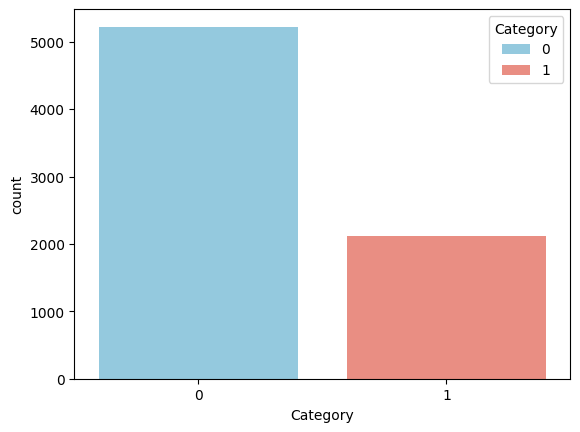

In [11]:
sns.countplot(x="Category", data=df, hue="Category", palette=["skyblue", "salmon"]);

### Lenght of the Tweets text

In [27]:
df["length"] = df.Text.str.len()
df['word_count'] = df['Text'].str.split().str.len()

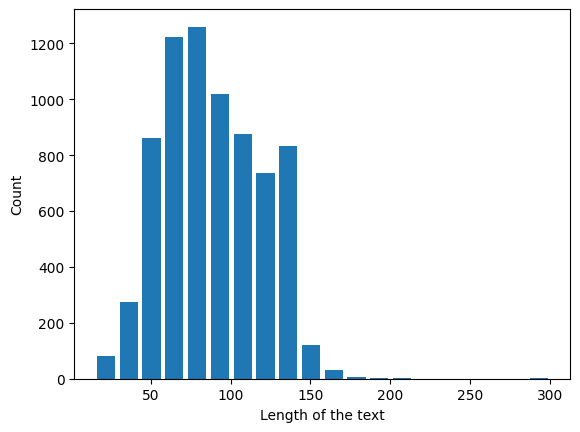

In [14]:
plt.hist(df.length, bins=20, rwidth=0.8)
plt.xlabel('Length of the text')
plt.ylabel('Count');

In [17]:
df[df.length > 200]

,Category,Text,length
1711,1,"@USUARIO @USUARIO Callate el hocico puta, ya quisieras ser mexicana Puta panameña de mierda tu pais es un asco igual que las personas que viven ahi puro puto negro de mierda que asco y luego son bien putos llorones ojala el bolillo se muera junto con toda la puta seleccion panameña aquerosa alv!!!\n",300
2718,1,Es si no sabia que habían dado mas caracteres para metar le la madre la madre a peña nieto peña chingas a tu madre chingas a tu madre a y tambien Alejandro murat igual que chingev a su madre mas de mil veces\n,208
3422,1,Ahora recuerdo por que no iba al cine en dias cercanos a la quincena... es cuando los nacos y la gente nefasta tiene para ir!! Que puto asco @USUARIO que sigas dejando entrar a menores a funciones B15\n,201
4334,1,"Putos los que no fueron a ayudar en el temblor, al chile yo si fui a remover los escombros a la condesa y hasta una pinche laptop y un Iphone me encontre y mi carnalito el Jonathan se trajo una pantalla.\n",204


### Difference in length of aggressiveness and no aggressiveness tweets

In [28]:
aggressive = df[df.Category == 1]
no_aggressive = df[df.Category == 0]

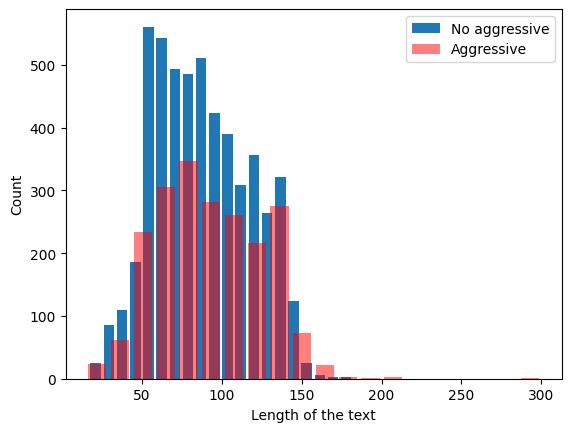

In [21]:
plt.hist(no_aggressive.length, bins=20, rwidth=0.8, label="No aggressive")
plt.hist(aggressive.length, bins=20, rwidth=0.8, label="Aggressive", alpha=0.5, color='red')
plt.xlabel('Length of the text')
plt.ylabel('Count')
plt.legend(loc="upper right");


## Word count

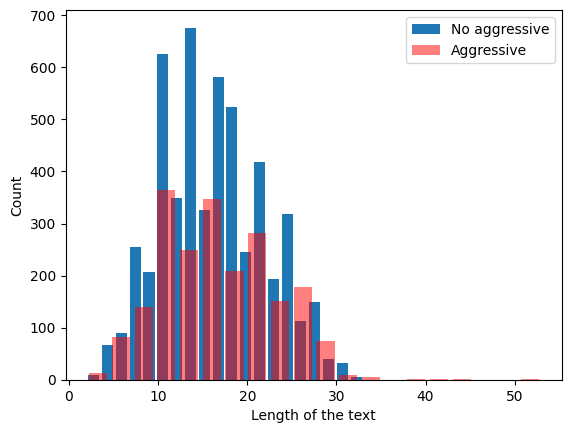

In [30]:
plt.hist(no_aggressive.word_count, bins=20, rwidth=0.8, label="No aggressive")
plt.hist(aggressive.word_count, bins=20, rwidth=0.8, label="Aggressive", alpha=0.5, color='red')
plt.xlabel('Length of the text')
plt.ylabel('Count')
plt.legend(loc="upper right");


## Unique characters

In [31]:
unique_chars = set(list(' '.join(df['Text'].values)))
print("".join(unique_chars))

😱기🏼🕵1과❤😉sR🤔\💔👰👌자k🐻😽🎊❄)해😓파🙇😏🌼🆙🎤🍷Só🤣:🍑c탄🌎💧*í🎶😯😖🙆😞👏🍜💜💚😆♥🔥🐕_🕯👸🐩Tq🐣😅👦✔🌩🙄@b🥚🐺🙏6😣🌧♀🦅🌑🖤🍌💭’🏠–🙌g8✨😂😍Ó#😴-🐷💖🤚2🔃hw😬😑z🤗W⬆전😻%🎵🤖💥D📷❣🌺╯ 🌶🎁😨&🤮r承😫Q🤯😲🐚🌃🔨👶😎‟´💆F😛🎈🐽🌸🍕é;🌈😼!🐶🚜😦¡😘🙂😈~😹Ü🎅¿4｀🦊☪×🚴p🏿💕╰🥂🍦😌̶$🕷👈H🤫«🤤÷®🍸—x✊년🙁e🔴🍴🌋π🤑☝원민😀a❕😁🤞🍻9🚂💅🍺>👋»스🐵🌮🗣👆😇😡🎉👊✅🍠💋ñ🤸😔💀🏈🌾🎃ツ엑🎺Ä사워ü7🍲+á👭🦎🇺🌹¬💪🧐🏽・😄🌟🆕📞🐖😃P🇨K😭👍/😠ò🥙X😿🐔💸💙🐍ʺ🇭🐮Mt🍾🔄ˮ👹🙋🤒♠🍔0👧🇱🐴💘🙉👿╭👀Y🤧J🇮💉💁💎💩•🙅G📄Z💗💃=u😶🙎😧Θ3“🏨방Á😰😮💛👻🍳단🇸v🤷j🤕5m😟︵👎츠😐Bć|🐐🤬🖋d😵🌽🚫L😙?☀🤓😪🐞🇲☔f(à]‘🤪"♡🌚
👠💓🏳►.🖕😥✋💰👩iU n╮'♂Ú🍵⚡👑🐃úÉ°🎄📟🍆❌☺🎸C😜😒🎧Í😢🏾O<⏫🏆😤😷🏻,☹¯포🤘😊🇳🔝⚽🇽Ñ🍄☃😳🙊✌📧…🙃”🤢🚙ìo지😩I💞A️🐊💯💤소😾🇷💄👅🔁E🇪l🌳😕🚗🎂N💏🇦💦y🤩력👬😋🤙🤛🗳V‍🙈😚👉‼[👱👇🤦🤐🕸😝🌷


## Unique words

In [32]:
def plot_cloud_word(text):
    stopwords = set(STOPWORDS)
    stopwords.update([])

    # Generate a word cloud image
    wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)

    # Display the generated image:
    # the matplotlib way:
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

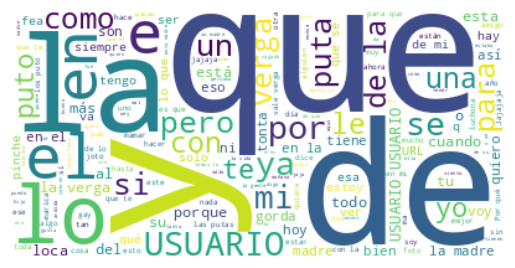

In [36]:
text = " ".join(comment for comment in no_aggressive.Text)
plot_cloud_word(text)

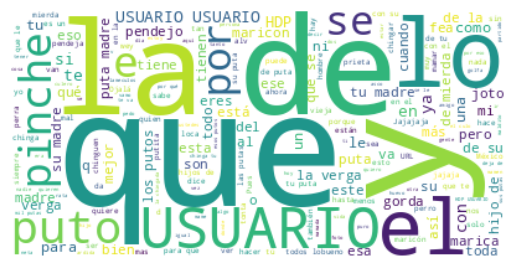

In [37]:
text = " ".join(comment for comment in aggressive.Text)
plot_cloud_word(text)